# Customer Churn Prediction — Classification

## Introduction

Customer churn is one of the most costly problems in business. Every
customer who leaves represents lost revenue that is expensive to replace.
The goal of this project is to build a machine learning model that
predicts whether a customer will churn before they leave — giving the
business time to intervene.

The dataset comes from a Telco company and contains 7,043 customer
records with features including tenure, monthly charges, total charges,
and senior citizen status.

**The goal:** Given customer data, predict whether they will churn (1)
or stay (0).

This notebook covers the full classification workflow:
1. Loading and inspecting the data
2. Cleaning and encoding the target variable
3. Selecting numeric features
4. Splitting data into training and test sets
5. Training a Logistic Regression model
6. Training a Decision Tree model
7. Evaluating both models using a confusion matrix and classification report
8. Comparing model performance

**Models used:**
- Logistic Regression — predicts probability of churn
- Decision Tree — learns decision rules from features

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report)

data = pd.read_csv("Telco-Customer-Churn.csv")

In [13]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [14]:
data.shape

(7043, 21)

In [15]:
data["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [17]:
data.isnull().sum().sort_values(ascending=False).head(10)

customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
OnlineSecurity     0
dtype: int64

In [18]:
data["TotalCharges"] = pd.to_numeric(data["TotalCharges"], errors="coerce")
data.dropna(subset=["TotalCharges"], inplace=True)

In [19]:
data["Churn"] = data["Churn"].map({"Yes":1, "No":0})
data["Churn"].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [22]:
numeric_data = data.select_dtypes(include=['number'])
numeric_data

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn
0,0,1,29.85,29.85,0
1,0,34,56.95,1889.50,0
2,0,2,53.85,108.15,1
3,0,45,42.30,1840.75,0
4,0,2,70.70,151.65,1
...,...,...,...,...,...
7038,0,24,84.80,1990.50,0
7039,0,72,103.20,7362.90,0
7040,0,11,29.60,346.45,0
7041,1,4,74.40,306.60,1


In [24]:
features = [col for col in numeric_data.columns if col != "Churn"]
target = "Churn"

X= data[features]
y= data[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

preds = model.predict(X_test)

In [26]:
accuracy_score(y_test, preds)

0.7803837953091685

In [27]:
precision_score(y_test, preds)

0.6245210727969349

In [28]:
recall_score(y_test, preds)

0.4358288770053476

In [29]:
f1_score(y_test, preds)

0.5133858267716536

In [30]:
classification_report(y_test, preds)

'              precision    recall  f1-score   support\n\n           0       0.82      0.91      0.86      1033\n           1       0.62      0.44      0.51       374\n\n    accuracy                           0.78      1407\n   macro avg       0.72      0.67      0.69      1407\nweighted avg       0.77      0.78      0.77      1407\n'

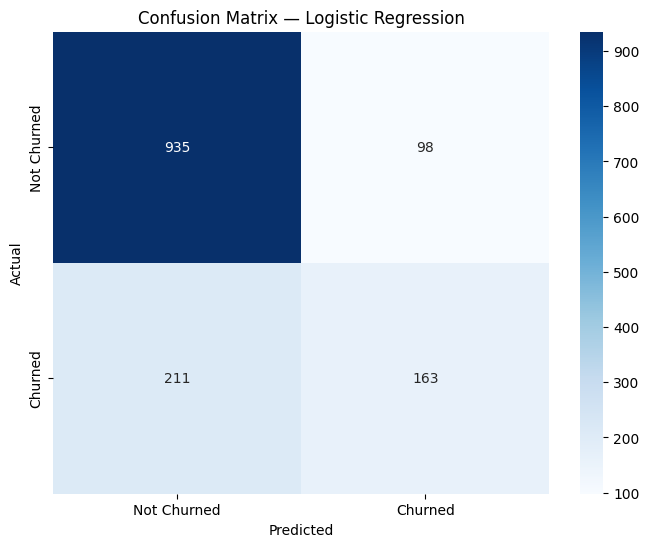

In [31]:
cm = confusion_matrix(y_test, preds)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Churned", "Churned"],
            yticklabels=["Not Churned", "Churned"])
plt.title("Confusion Matrix — Logistic Regression")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

In [33]:
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

In [34]:
accuracy_score(y_test, dt_pred)

0.767590618336887

In [35]:
precision_score(y_test, dt_pred)

0.5775577557755776

In [36]:
recall_score(y_test, dt_pred)

0.4679144385026738

In [37]:
f1_score(y_test, dt_pred)

0.51698670605613

In [38]:
classification_report(y_test, dt_pred)

'              precision    recall  f1-score   support\n\n           0       0.82      0.88      0.85      1033\n           1       0.58      0.47      0.52       374\n\n    accuracy                           0.77      1407\n   macro avg       0.70      0.67      0.68      1407\nweighted avg       0.76      0.77      0.76      1407\n'

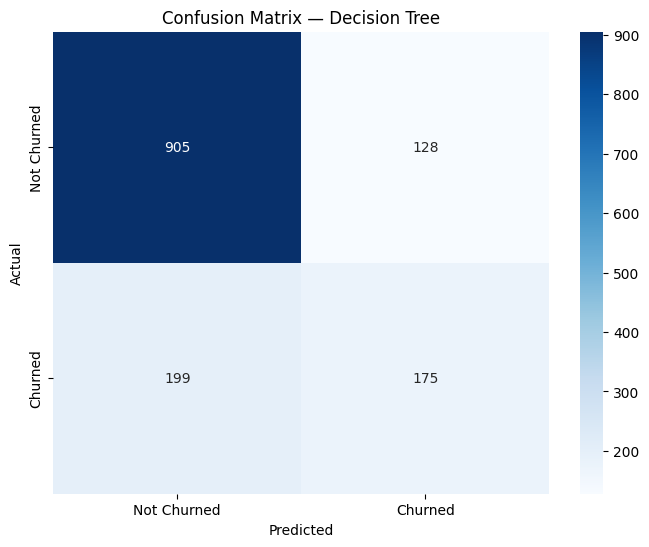

In [39]:
cm_dt = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Churned", "Churned"],
            yticklabels=["Not Churned", "Churned"])
plt.title("Confusion Matrix — Decision Tree")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

## Conclusion

Both models successfully predicted customer churn with reasonable accuracy.

**Logistic Regression** achieved 78% accuracy and was more precise,
fewer false alarms. However it missed 211 customers who actually churned,
which in a real business represents significant lost revenue.

**Decision Tree** caught 12 more churners (175 vs 163) at the cost of
more false alarms (128 vs 98). For a churn problem, catching more real
churners is generally more valuable, it's cheaper to offer a discount
to a loyal customer than to lose a churning one entirely.

**Key takeaway:** No model is perfect on imbalanced data. The next step
would be to apply techniques like SMOTE to balance the classes, or try
Random Forest and XGBoost for stronger performance.

This project introduced core classification concepts, confusion matrix,
precision, recall, F1 score and demonstrated how two different models
make different trade-offs on the same problem.